# Import

In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch


ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

In [2]:
from brighteyes_flim import mcs
from brighteyes_flim import flism
from brighteyes_flim.flism import Alignment

print(mcs.__file__)
print(flism.__file__)


/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/dataio/mcs.py
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/flism.py


# Imported helpers

In [3]:

IRF_from_data_deconvolution = Alignment.IRF_from_data_deconvolution
fit_model_data = Alignment.fit_model_data
hist_for_plot = Alignment.hist_for_plot
perform_fit_data = Alignment.perform_fit_data
#perform_fit_data_ng = Alignment.perform_fit_data_ng
phasor_delay_from_hist = Alignment.phasor_delay_from_hist

# Unit convention used below:
# - *_ns: nanoseconds
# - *_bins: histogram-bin shifts
# - *_rad: phase in radians
# - *_norm: normalized 0..1 phasor / fit amplitude


# Tests
It this thest we want to generate by simulation the data, the irf and the reference measurements. All of them with a different delay from the T/2 time point.


# Processing (Data and Reference) EXP

From here we assume that we have the Data (data_sim) and the Reference (ref_sim) datasets and we simply know that the Reference is a single-exponential decay from which we know the fluorescence lifetime tau_R

Given the fact that we know that the reference is a single-exponential decay and we know the lifetime tau_R, we can deconvolve the reference dataset to estimate irf for this specific measurement. We call it est_irf_ref to distinguish from the irf_sim, which is a simulated irf dataset, and irf which is the noise-free (and centered in T/2) irf used for all simulation

In [4]:
f_ref = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"
tau_ref_ns = 2.5

f_data = "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/01_Convallaria_DFD_40MHz-17-03-2026-16-59-41.h5"


ref_data_6d, metadata_ref = mcs.load(f_ref)
data_hist_6d, metadata_data = mcs.load(f_data)

#print(a[1].dfd_activate)
#print(a[1].dfd_freq)
#print(a[1].dfd_nbins)

ref_hist_org = ref_data_6d[0, 0, :, :, :, 12].sum(axis=(0, 1))
data_hist = data_hist_6d[0, 0, :, :, :, 12].sum(axis=(0, 1))

<Figure size 640x480 with 0 Axes>

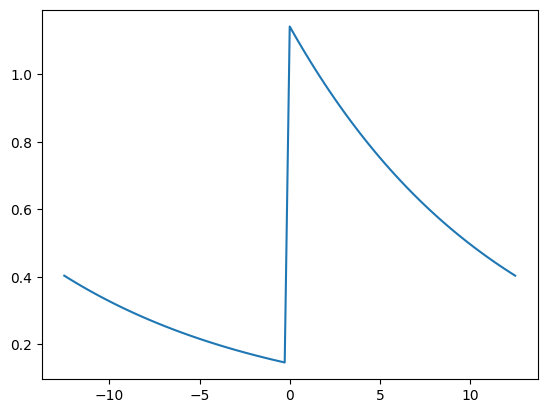

<Figure size 640x480 with 0 Axes>

In [5]:


def model_data(t, C, tau, T, shift_bins=0.):
    """
    Periodic mono-exponential decay model.

    Units:
    - ``t`` and ``T`` are in nanoseconds.
    - ``tau`` is in nanoseconds.
    - ``C`` is the model amplitude. When the fit helpers are used, it is a
    - ``shift_bins`` is in histogram bins, because it is applied through
        normalized 0..1 scale factor.
    """
    t_ns = Alignment.to_numpy_1d(t, dtype=float)
    C_norm = float(C)
    tau_ns = float(tau)
    period_ns = float(T)
    shift_ns = float(shift_bins * (period_ns / len(t_ns)))

    
    t_ns = np.mod(t_ns - shift_ns, period_ns)

    # model_hist = C_norm * (
    #     np.heaviside(t_ns - offset_ns, 1) + 1 / (np.exp(period_ns / tau_ns) - 1)
    # ) * np.exp((-t_ns + offset_ns) / tau_ns)

    model_hist =  C_norm * (
        np.exp(-(np.mod(t_ns, period_ns)) / tau_ns)
        / (1 - np.exp(-period_ns / tau_ns))
    )

    return model_hist


t_ns=np.linspace(-12.5,12.5,91)
offset_ns = 0
shift_bins=0
tau_ns = 12
C_norm= 1

model_hist=model_data(t_ns, C_norm, tau_ns, 25., shift_bins=shift_bins)


plt.plot(t_ns, model_hist)

plt.figure()



ROLL BINS =  0
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


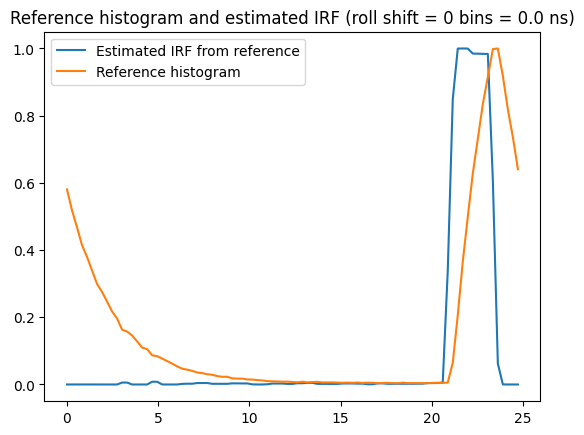

initial_dT_ns/nbin = -8.133739418285526 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 24.53233586092165
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = -2.2345437962322876 ns
Initial delay between data and reference = -8.13373941828553 bins
C_fit_norm = 1.0000000130216358
dT_fit_bins = -8.133739395301447
dT_fit_ns = -2.2345437899179803
tau_fit_ns = 1.1826943137698869
delay between data and reference from fit = 22.76545621008202 ns


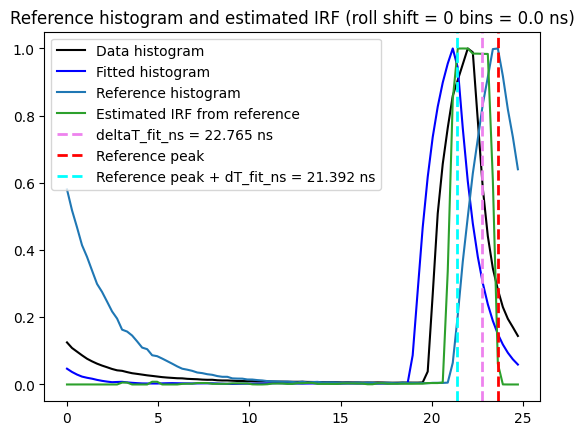

ROLL BINS =  10
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


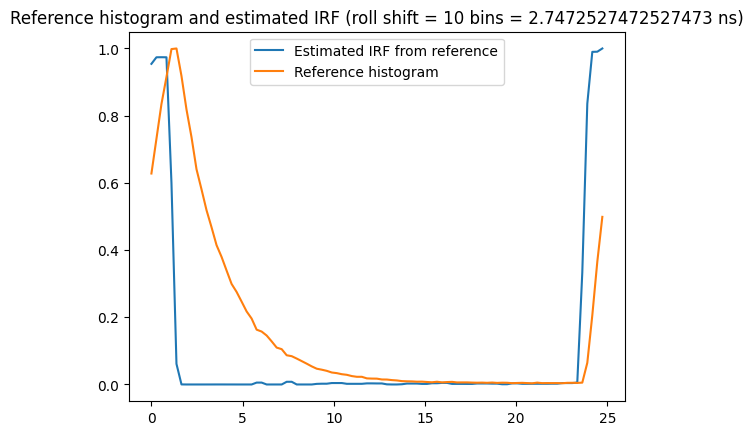

initial_dT_ns/nbin = 72.86626058171446 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 2.2795886081743975
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 20.018203456514964 ns
Initial delay between data and reference = -18.133739418285543 bins
C_fit_norm = 1.0000000205166295
dT_fit_bins = -18.13373941777421
dT_fit_ns = -4.981796543344563
tau_fit_ns = 1.1834236717578164
delay between data and reference from fit = 20.01820345665544 ns


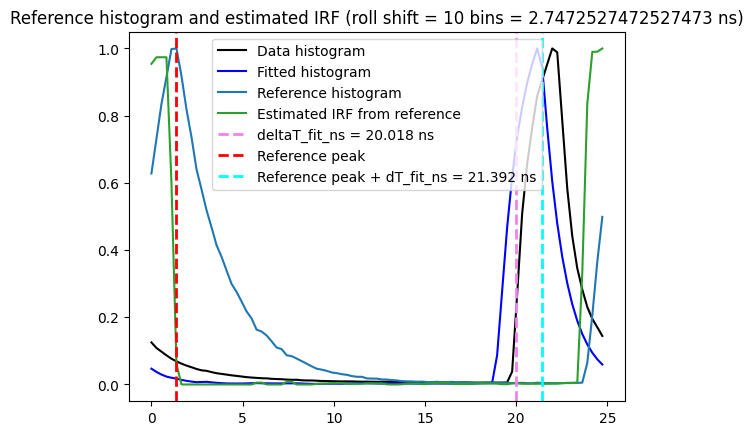

ROLL BINS =  37
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


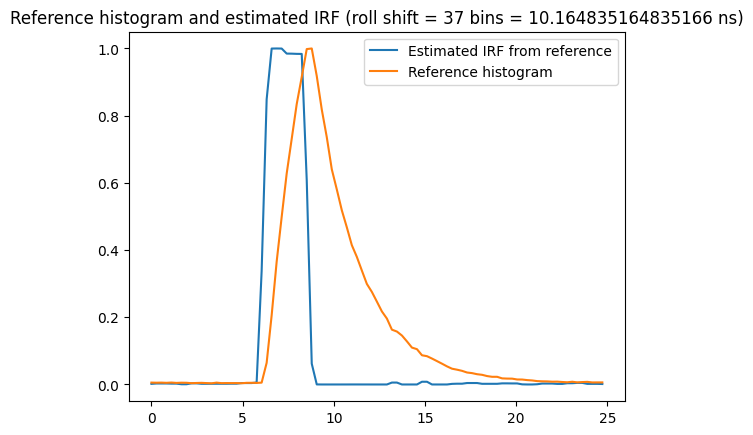

initial_dT_ns/nbin = 45.86626058171446 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 9.697171025756816
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 12.600621038932545 ns
Initial delay between data and reference = -45.13373941828554 bins
C_fit_norm = 1.0000000646608396
dT_fit_bins = -45.13373941381607
dT_fit_ns = -12.399378959839582
tau_fit_ns = 1.182389660989547
delay between data and reference from fit = 12.600621040160421 ns


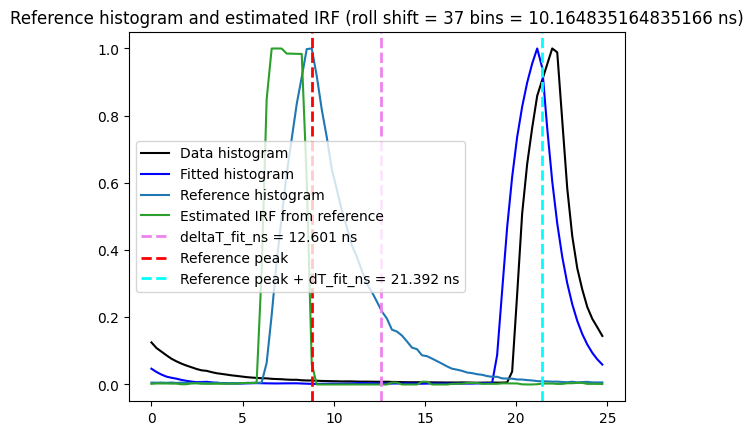

ROLL BINS =  38
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


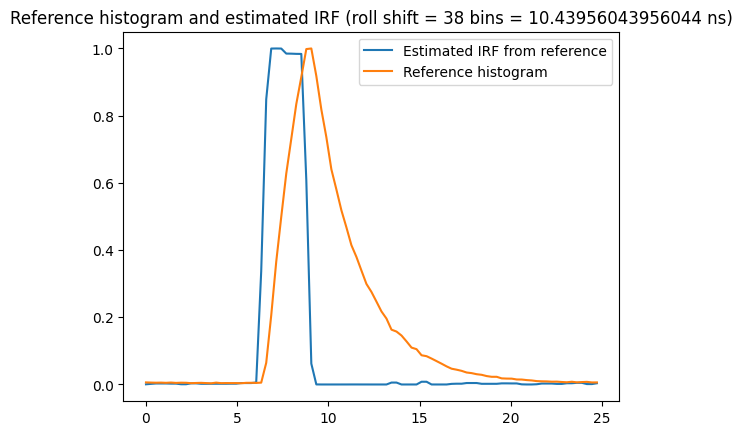

initial_dT_ns/nbin = 44.866260581714464 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 9.97189630048209
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 12.32589576420727 ns
Initial delay between data and reference = 44.86626058171447 bins
C_fit_norm = 1.0000001109496992
dT_fit_bins = 44.86626048332257
dT_fit_ns = 12.32589573717653
tau_fit_ns = 1.1826571423412107
delay between data and reference from fit = 12.32589573717653 ns


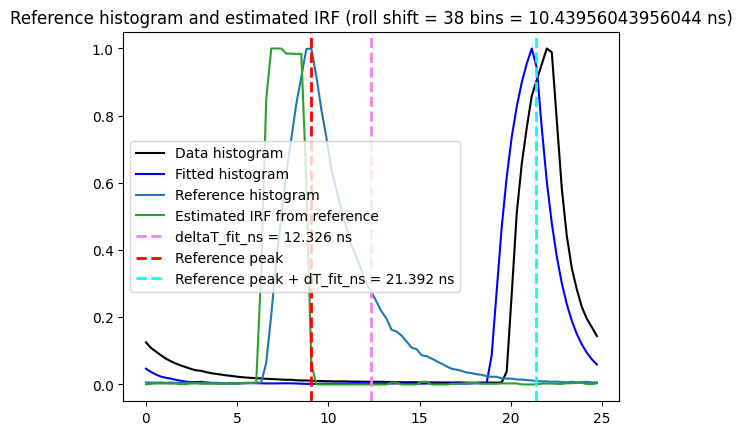

ROLL BINS =  39
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


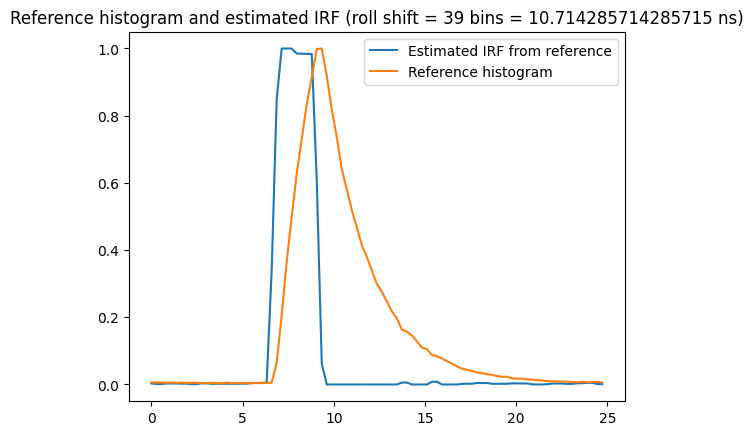

initial_dT_ns/nbin = 43.86626058171446 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 10.246621575207365
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 12.051170489481995 ns
Initial delay between data and reference = 43.86626058171446 bins
C_fit_norm = 1.0000000749851152
dT_fit_bins = 43.86626053762718
dT_fit_ns = 12.051170477370105
tau_fit_ns = 1.183205404532718
delay between data and reference from fit = 12.051170477370105 ns


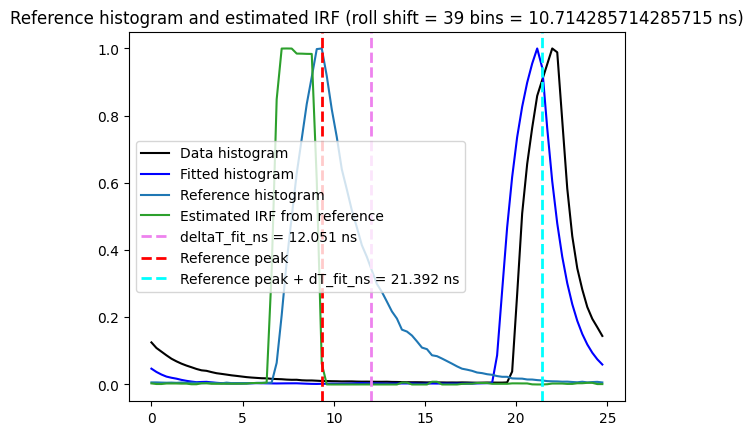

ROLL BINS =  40
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


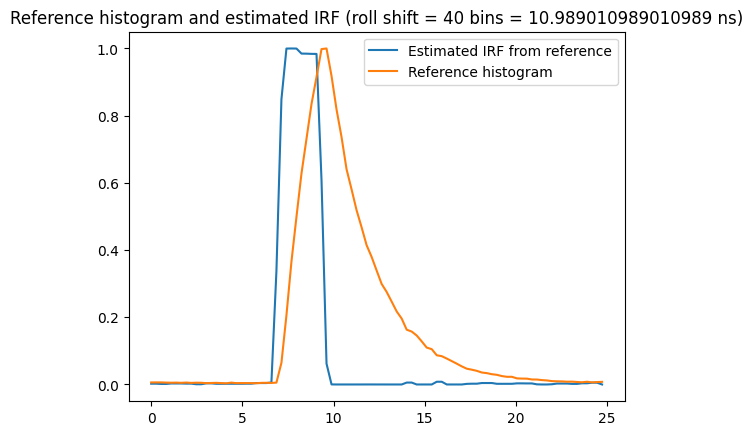

initial_dT_ns/nbin = 42.86626058171446 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 10.521346849932641
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 11.77644521475672 ns
Initial delay between data and reference = 42.86626058171446 bins
C_fit_norm = 0.9999999740248724
dT_fit_bins = 42.8662604518367
dT_fit_ns = 11.776445179076019
tau_fit_ns = 1.1826198171123283
delay between data and reference from fit = 11.776445179076019 ns


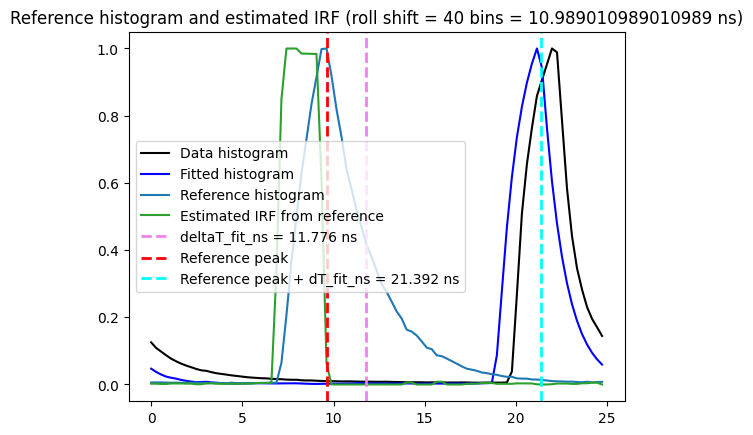

ROLL BINS =  41
dt_ns = 0.27472527472527475 ns, period_ns = 25.0 ns
ref_hist sum = 245964 counts
ref_hist shape = (91,)


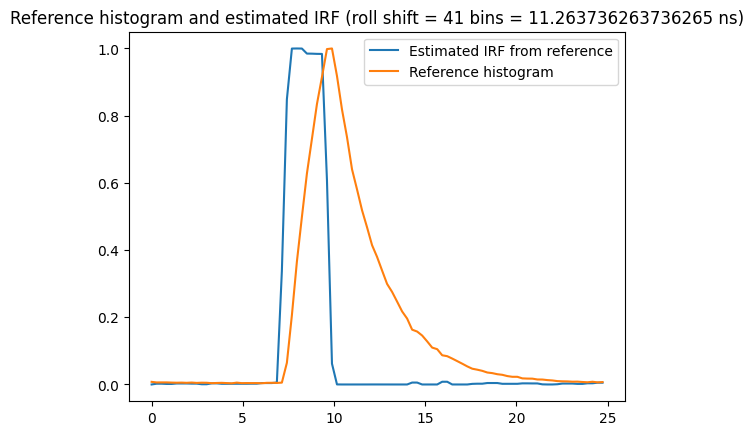

initial_dT_ns/nbin = 41.86626058171446 bins
delay_data_ns = 22.29779206468936
delay_ref_ns = 10.796072124657915
nbin = 91   bins, dt_ns = 0.27472527472527475 ns
Initial delay between data and reference = 11.501719940031446 ns
Initial delay between data and reference = 41.86626058171446 bins
C_fit_norm = 0.9999999997006944
dT_fit_bins = 41.866260582326156
dT_fit_ns = 11.501719940199495
tau_fit_ns = 1.1826579465962523
delay between data and reference from fit = 11.501719940199495 ns


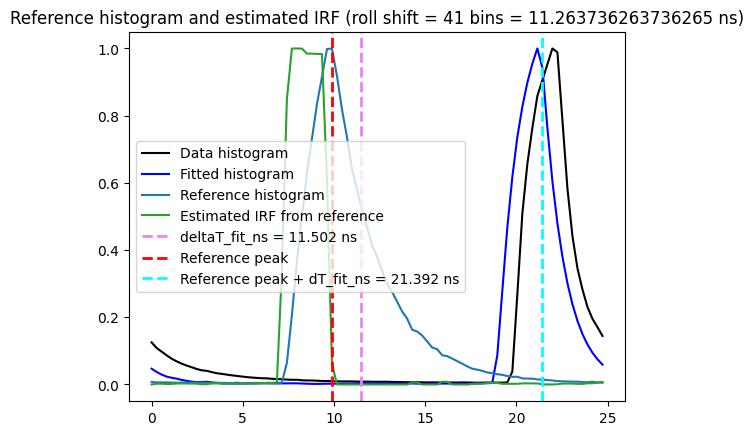

In [6]:
mode = "irf_shift"
mode = "model_shift"
 


for ref_roll_bins in [0,10,] + list(range(37, 42, 1)):
    print("ROLL BINS = ", ref_roll_bins)
    #ref_roll_bins = 26
    ref_hist = np.roll(ref_hist_org, ref_roll_bins)

    nbin = metadata_data.dfd_nbins 
    excitation_freq_hz = metadata_data.dfd_freq * 1e6

    period_ns = 1 / excitation_freq_hz * 1e9
    dt_ns = period_ns / nbin
    t_ns = np.arange(nbin) * dt_ns
    C_ref = 3e3
    print(f"dt_ns = {dt_ns} ns, period_ns = {period_ns} ns")


    print(f"ref_hist sum = {ref_hist.sum()} counts")
    print(f"ref_hist shape = {ref_hist.shape}")

    est_irf_ref = IRF_from_data_deconvolution(ref_hist, t_ns, C_ref, tau_ref_ns, period_ns, iterations=3000)

    norm_est_irf_ref = est_irf_ref / torch.sum(est_irf_ref)

    plt.plot(t_ns, est_irf_ref / max(est_irf_ref), label='Estimated IRF from reference')
    plt.plot(t_ns, ref_hist / max(ref_hist), label='Reference histogram')
    plt.title(f"Reference histogram and estimated IRF (roll shift = {ref_roll_bins} bins = {ref_roll_bins * dt_ns} ns)")
    plt.legend()
    plt.show()



    _, _, delay_data_ns = phasor_delay_from_hist(data_hist, period_ns)
    _, _, delay_ref_ns = phasor_delay_from_hist(ref_hist, period_ns)


    initial_dT_ns = delay_data_ns - delay_ref_ns 
    initial_dT_bins = np.mod(((initial_dT_ns / dt_ns)+ nbin/2.), nbin) - nbin/2. 
    print(f"initial_dT_ns/nbin = {initial_dT_ns / dt_ns} bins")
    print(f"delay_data_ns = {delay_data_ns}")
    print(f"delay_ref_ns = {delay_ref_ns}")
    print(f"nbin = {nbin}   bins, dt_ns = {dt_ns} ns")
    print(f"Initial delay between data and reference = {initial_dT_ns} ns")
    print(f"Initial delay between data and reference = {initial_dT_bins} bins")

    fit_result, fit_cov = perform_fit_data(
        t_ns,
        data_hist,
        est_irf_ref,
        period_ns,
        initial_dT=initial_dT_bins,
        mode=mode
    )
    C_fit_norm = fit_result["C"]
    dT_fit_bins = fit_result["dT"]
    tau_fit_ns = fit_result["tau"]

    fitted_hist = fit_model_data(t_ns, C_fit_norm, dT_fit_bins, tau_fit_ns, 
                                 irf=est_irf_ref, period=period_ns, mode=mode)

    deltaT_fit_ns = np.mod(dT_fit_bins, nbin)*dt_ns


    print(f"C_fit_norm = {C_fit_norm}")
    print(f"dT_fit_bins = {dT_fit_bins}")
    print(f"dT_fit_ns = {dT_fit_bins * dt_ns}")
    print(f"tau_fit_ns = {tau_fit_ns}")
    print(f"delay between data and reference from fit = {deltaT_fit_ns} ns")

    plt.figure()
    plt.plot(t_ns, data_hist / max(data_hist), label='Data histogram', color='black')
    plt.plot(t_ns, fitted_hist / max(fitted_hist), label='Fitted histogram', color='blue')

    plt.plot(t_ns, ref_hist / max(ref_hist), label='Reference histogram', color='tab:blue')
    plt.plot(t_ns, est_irf_ref / max(est_irf_ref), label='Estimated IRF from reference', color='tab:green')
    plt.title(f"Reference histogram and estimated IRF (roll shift = {ref_roll_bins} bins = {ref_roll_bins * dt_ns} ns)")
    plt.legend()

    plt.axvline(x=deltaT_fit_ns, linestyle='--', color='violet', linewidth=2, label=f"deltaT_fit_ns = {deltaT_fit_ns:.3f} ns")

    ref_peak_ns = np.mod(t_ns[ref_hist.argmax()], period_ns)
    plt.axvline(x=ref_peak_ns, linestyle='--', color='red', linewidth=2, label='Reference peak')

    fit_shifted_ref_peak_ns = np.mod(ref_peak_ns + deltaT_fit_ns, period_ns)
    plt.axvline(x=fit_shifted_ref_peak_ns, linestyle='--', color='cyan', linewidth=2, label=f"Reference peak + dT_fit_ns = {fit_shifted_ref_peak_ns:.3f} ns")
    plt.legend()
    plt.show()

Now we fit the Data dataset with the irf estimated from the reference

The fit parameter `dT_fit_bins` is a shift in histogram bins between the data histogram and the IRF/reference histogram. It is not a delay with respect to `T/2`; convert it to nanoseconds with `dT_fit_bins * dt_ns`.

IRF phase_rad = 2.1180 rad, phasor_norm = 0.9614, delay_ns = 8.4271 ns
DATA phase_rad = 5.6040 rad, phasor_norm = 0.8434, delay_ns = 22.2978 ns
Delta(DATA - IRF) = 13.8707 ns


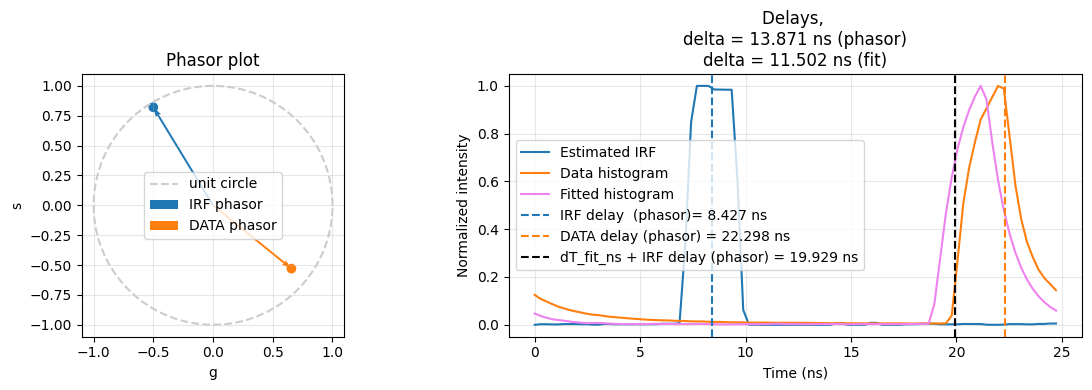

In [7]:
irf_hist = hist_for_plot(est_irf_ref)
data_hist = hist_for_plot(data_hist)

phasor_irf, phase_irf_rad, delay_irf_ns = phasor_delay_from_hist(irf_hist, period_ns)
phasor_data, phase_data_rad, delay_data_ns = phasor_delay_from_hist(data_hist, period_ns)
phasor_irf_norm = np.abs(phasor_irf)
phasor_data_norm = np.abs(phasor_data)
delta_delay_ns = np.mod(delay_data_ns - delay_irf_ns, period_ns)

print(f"IRF phase_rad = {phase_irf_rad:.4f} rad, phasor_norm = {phasor_irf_norm:.4f}, delay_ns = {delay_irf_ns:.4f} ns")
print(f"DATA phase_rad = {phase_data_rad:.4f} rad, phasor_norm = {phasor_data_norm:.4f}, delay_ns = {delay_data_ns:.4f} ns")
print(f"Delta(DATA - IRF) = {delta_delay_ns:.4f} ns")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

theta = np.linspace(0, 2 * np.pi, 400)
axes[0].plot(np.cos(theta), np.sin(theta), '--', color='0.8', label='unit circle')
axes[0].quiver(0, 0, np.real(phasor_irf), np.imag(phasor_irf), angles='xy', scale_units='xy', scale=1, color='tab:blue', label='IRF phasor')
axes[0].quiver(0, 0, np.real(phasor_data), np.imag(phasor_data), angles='xy', scale_units='xy', scale=1, color='tab:orange', label='DATA phasor')
axes[0].scatter([np.real(phasor_irf), np.real(phasor_data)], [np.imag(phasor_irf), np.imag(phasor_data)], color=['tab:blue', 'tab:orange'])
axes[0].set_xlabel('g')
axes[0].set_ylabel('s')
axes[0].set_title('Phasor plot')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

delay_data_fit_ns = np.mod(delay_irf_ns + deltaT_fit_ns, period_ns)

axes[1].plot(t_ns, irf_hist / irf_hist.max(), label='Estimated IRF', color='tab:blue')
axes[1].plot(t_ns, data_hist / data_hist.max(), label='Data histogram', color='tab:orange')
axes[1].plot(t_ns, fitted_hist / fitted_hist.max(), label='Fitted histogram', color='violet')
axes[1].axvline(delay_irf_ns, linestyle='--', color='tab:blue', label=f'IRF delay  (phasor)= {delay_irf_ns:.3f} ns')
axes[1].axvline(delay_data_ns, linestyle='--', color='tab:orange', label=f'DATA delay (phasor) = {delay_data_ns:.3f} ns')
axes[1].axvline(delay_data_fit_ns, linestyle='--', color='k', label=f'dT_fit_ns + IRF delay (phasor) = {delay_data_fit_ns:.3f} ns')
axes[1].set_xlabel('Time (ns)')
axes[1].set_ylabel('Normalized intensity')
axes[1].set_title(f'Delays, \ndelta = {delta_delay_ns:.3f} ns (phasor)\ndelta = {deltaT_fit_ns:.3f} ns (fit)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()


plt.tight_layout()
plt.show()


Roll shift applied to reference: 0 bins = 0.0 ns
delay_data_ns = 22.29779206468936
delay_ref_shifted_ns = 24.53233586092165
Initial delay between data and reference = -2.2345437962322876 ns = -8.13373941828553 bins
Fit parameters: C_fit_norm = 0.9999999250831025 +/- 89617900.52645643, dT_fit_bins = -8.133739346503273 +/- 740474393.317195, tau_fit_ns = 1.1821474516284298 +/- 2.6011552734124797
Roll shift applied to reference: 1 bins = 0.27472527472527475 ns
delay_data_ns = 22.29779206468936
delay_ref_shifted_ns = 24.807061135646926
Initial delay between data and reference = -2.509269070957565 ns = -9.133739418285536 bins
Fit parameters: C_fit_norm = 0.9999999055401497 +/- 59415864.739126794, dT_fit_bins = -9.133739396902167 +/- 715273737.6315771, tau_fit_ns = 1.1819722491829912 +/- 2.6479087674711663
Roll shift applied to reference: 2 bins = 0.5494505494505495 ns
delay_data_ns = 22.29779206468936
delay_ref_shifted_ns = 0.0817864103721998
Initial delay between data and reference = 22.216

,roll_shift_bins,roll_shift_ns,initial_dT_bins,C_fit_norm,C_fit_perr_norm,dT_fit_bins,dT_fit_perr_bins,dT_fit_ns,tau_fit_ns,tau_fit_perr_ns,phasor_delta_ns
0,0,0.000000,-8.133739,1.0,8.961790e+07,-8.133739,7.404744e+08,22.765456,1.182147,2.601155,0.132229
1,1,0.274725,-9.133739,1.0,5.941586e+07,-9.133739,7.152737e+08,22.490731,1.181972,2.647909,24.857504
2,2,0.549451,-10.133739,1.0,9.743213e+07,-10.133739,2.570726e+08,22.216006,1.182141,2.677490,24.582779
3,3,0.824176,-11.133739,1.0,2.461543e+07,-11.133739,7.219019e+08,21.941280,1.182084,2.581433,24.308054
4,4,1.098901,-12.133739,1.0,7.791534e+07,-12.133739,3.178093e+08,21.666555,1.182123,2.727401,24.033328
5,5,1.373626,-13.133739,1.0,4.200988e+07,-13.133740,3.354579e+08,21.391830,1.181972,2.915323,23.758603
6,6,1.648352,-14.133739,1.0,1.313982e+08,-14.133739,1.343023e+09,21.117105,1.182083,2.603908,23.483769
7,7,1.923077,-15.133739,1.0,2.145854e+07,-15.133739,6.382467e+08,20.842379,1.181791,3.111928,23.209028
8,8,2.197802,-16.133739,1.0,8.188772e+07,-16.133740,4.775310e+08,20.567654,1.182373,2.673090,22.934458
9,9,2.472527,-17.133739,1.0,8.132473e+07,-17.133739,1.356383e+09,20.292929,1.182266,2.587724,22.659718


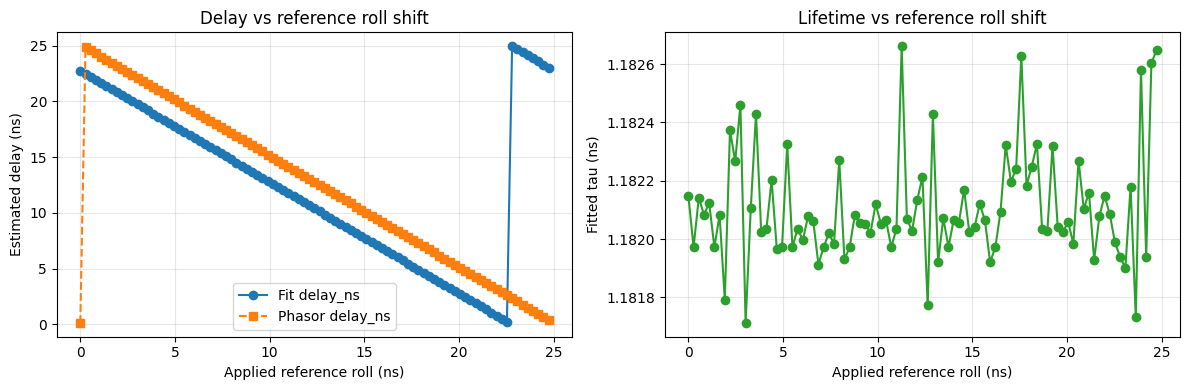

In [8]:
# Repeat the same workflow for multiple reference shifts.
# Edit `roll_shift_bins_values` as needed. Example single value: [10]
mode = "model_shift"

import pandas as pd

roll_shift_bins_values = list(range(0, nbin, 1))

with h5py.File(f_ref, 'r') as hf_ref:
    ref_hist_raw = hf_ref['data'][0, 0, :, :, :, 12].sum(axis=(0, 1))

with h5py.File(f_data, 'r') as hf_data:
    data_hist_raw = hf_data['data'][0, 0, :, :, :, 12].sum(axis=(0, 1))

scan_results = []

for roll_shift_bins in roll_shift_bins_values:
    ref_hist_shifted = np.roll(ref_hist_raw, roll_shift_bins)

    est_irf_ref_loop = IRF_from_data_deconvolution(ref_hist_shifted, t_ns, C_ref, tau_ref_ns, period_ns, iterations=300)

    _, _, delay_data_ns_loop = phasor_delay_from_hist(data_hist_raw, period_ns)
    _, _, delay_ref_shifted_ns = phasor_delay_from_hist(ref_hist_shifted, period_ns)


    initial_dT_ns = delay_data_ns_loop - delay_ref_shifted_ns 
    initial_dT_bins = np.mod(((initial_dT_ns / dt_ns)+ nbin/2.), nbin) - nbin/2. 


    print(f"Roll shift applied to reference: {roll_shift_bins} bins = {roll_shift_bins * dt_ns} ns")
    print(f"delay_data_ns = {delay_data_ns_loop}")
    print(f"delay_ref_shifted_ns = {delay_ref_shifted_ns}")

    print(f"Initial delay between data and reference = {initial_dT_ns} ns = {initial_dT_bins} bins")

    fit_result_loop, conv = perform_fit_data(
        t_ns,
        data_hist_raw,
        est_irf_ref_loop,
        period_ns,
        initial_dT=initial_dT_bins,
        mode=mode
    )

    perr = np.sqrt(np.diag(conv))
    C_fit_loop_norm = fit_result_loop['C']
    dT_fit_loop_bins = fit_result_loop['dT']
    tau_fit_loop_ns = fit_result_loop['tau']
    print(
        f"Fit parameters: C_fit_norm = {C_fit_loop_norm} +/- {perr[0]}, "
        f"dT_fit_bins = {dT_fit_loop_bins} +/- {perr[1]}, "
        f"tau_fit_ns = {tau_fit_loop_ns} +/- {perr[2]}"
    )
    fitted_hist_loop = fit_model_data(t_ns, C_fit_loop_norm, dT_fit_loop_bins, tau_fit_loop_ns, irf=est_irf_ref_loop, period=period_ns, mode=mode)

    dT_fit_loop_ns = np.mod(dT_fit_loop_bins * dt_ns, period_ns)

    irf_hist_loop = hist_for_plot(est_irf_ref_loop)
    data_hist_loop = hist_for_plot(data_hist_raw)
    _, _, delay_irf_ns_loop = phasor_delay_from_hist(irf_hist_loop, period_ns)
    _, _, delay_data_ns_loop = phasor_delay_from_hist(data_hist_loop, period_ns)
    delta_delay_ns_loop = np.mod(delay_data_ns_loop - delay_irf_ns_loop, period_ns)

    scan_results.append({
        'roll_shift_bins': roll_shift_bins,
        'roll_shift_ns': roll_shift_bins * dt_ns,
        'initial_dT_bins': initial_dT_bins,
        'C_fit_norm': C_fit_loop_norm,
        'C_fit_perr_norm': perr[0],
        'dT_fit_bins': dT_fit_loop_bins,
        'dT_fit_perr_bins': perr[1],
        'dT_fit_ns': dT_fit_loop_ns,
        'tau_fit_ns': tau_fit_loop_ns,
        'tau_fit_perr_ns': perr[2],
        'phasor_delta_ns': delta_delay_ns_loop,
        'ref_peak_ns': np.mod(t_ns[ref_hist_shifted.argmax()], period_ns),
        'fitted_peak_ns': np.mod(t_ns[hist_for_plot(fitted_hist_loop).argmax()], period_ns),
    })

scan_results_df = pd.DataFrame(scan_results)
table_columns = [
    'roll_shift_bins',
    'roll_shift_ns',
    'initial_dT_bins',
    'C_fit_norm',
    'C_fit_perr_norm',
    'dT_fit_bins',
    'dT_fit_perr_bins',
    'dT_fit_ns',
    'tau_fit_ns',
    'tau_fit_perr_ns',
    'phasor_delta_ns',
]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("TEST")
display(scan_results_df[table_columns].round(6))

roll_shift_ns = [row['roll_shift_ns'] for row in scan_results]
dT_fit_ns = [row['dT_fit_ns'] for row in scan_results]
phasor_delta_ns = [row['phasor_delta_ns'] for row in scan_results]
tau_fit_ns = [row['tau_fit_ns'] for row in scan_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(roll_shift_ns, dT_fit_ns, 'o-', label='Fit delay_ns')
axes[0].plot(roll_shift_ns, phasor_delta_ns, 's--', label='Phasor delay_ns')
axes[0].set_xlabel('Applied reference roll (ns)')
axes[0].set_ylabel('Estimated delay (ns)')
axes[0].set_title('Delay vs reference roll shift')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(roll_shift_ns, tau_fit_ns, 'o-', color='tab:green')
axes[1].set_xlabel('Applied reference roll (ns)')
axes[1].set_ylabel('Fitted tau (ns)')
axes[1].set_title('Lifetime vs reference roll shift')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
